In [89]:
from datasets import load_dataset
import torch
import numpy as np
import chess
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [5]:
dataset = load_dataset(
    "mateuszgrzyb/lichess-stockfish-normalized",
    split="train",
    cache_dir="./training_data"
)

Loading dataset shards:   0%|          | 0/35 [00:00<?, ?it/s]

In [6]:
min_depth = 30

filtered_ds = dataset.filter(lambda x: x["depth"] >= min_depth, num_proc=8)
print(len(filtered_ds))

split1 = filtered_ds.train_test_split(test_size=0.2, seed=42)

train_ds = split1["train"]
temp_ds  = split1["test"]

# second split: val vs test
split2 = temp_ds.train_test_split(test_size=0.5, seed=42)

val_ds   = split2["train"]
test_ds  = split2["test"]

66271195


In [ ]:
#see https://official-stockfish.github.io/docs/nnue-pytorch-wiki/docs/nnue.html#halfkp
PIECE_MAP = {
    chess.PAWN: 0,
    chess.KNIGHT: 1,
    chess.BISHOP: 2,
    chess.ROOK: 3,
    chess.QUEEN: 4,
}

# using the same formula provided by the stockfish site
def halfkp_index(piece, piece_square, king_square, perspective): # perspective is who is "us"
    piece_type = PIECE_MAP[piece.piece_type]
    piece_color = 0 if piece.color == perspective else 1
    p_idx = piece_type * 2 + piece_color
    return piece_square + (p_idx + king_square * 10) * 64

def flip_square(sq):
    file = sq % 8
    rank = sq // 8
    return (7 - rank) * 8 + file

def extract_halfkp(board, perspective):
    feats = []

    king_sq = board.king(perspective)

    if perspective == chess.BLACK:
        king_sq = flip_square(king_sq)

    for sq, piece in board.piece_map().items():
        if piece.piece_type == chess.KING:
            continue

        if perspective == chess.BLACK:
            sq = flip_square(sq)

        feats.append(
            halfkp_index(piece, sq, king_sq, perspective)
        )

    return feats



In [157]:
fen1 = "r1bqk1nr/pppp1ppp/2n5/2b1p1N1/2B1P3/8/PPPP1PPP/RNBQK2R b KQkq - 0 1"
fen2 = "r1bNk2r/pppp2pp/2n4n/2b1p3/2B1P3/8/PPPP1PPP/RNBQK2R w KQkq - 0 1"
fen3 = "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq e3 0 1"
print(extract_halfkp(chess.Board(fen1), chess.WHITE))
print(extract_halfkp(chess.Board(fen2), chess.WHITE))
print(extract_halfkp(chess.Board(fen3), chess.WHITE))

[3071, 2814, 3195, 2938, 3064, 2679, 2678, 2677, 2675, 2674, 2673, 2672, 2794, 2726, 2660, 2914, 2588, 2842, 2575, 2574, 2573, 2571, 2570, 2569, 2568, 2951, 3075, 2818, 2689, 2944]
[3071, 2747, 2938, 3064, 2679, 2678, 2675, 2674, 2673, 2672, 2799, 2794, 2660, 2914, 2588, 2842, 2575, 2574, 2573, 2571, 2570, 2569, 2568, 2951, 3075, 2818, 2689, 2944]
[3071, 2814, 2941, 2938, 2809, 3064, 2679, 2678, 2677, 2676, 2675, 2674, 2673, 2672, 2575, 2574, 2573, 2572, 2571, 2570, 2569, 2568, 2951, 2694, 2821, 3075, 2818, 2689, 2944]


In [158]:
class ChessDataset(Dataset):
    def __init__(self, data, max_samples=None, balance_mode=None, seed=42):
        self.ds = data
        self.balance_mode = balance_mode

        rng = np.random.default_rng(seed)

        # initial candidate indices
        if max_samples is not None:
            indices = rng.choice(len(self.ds), size=max_samples, replace=False)
        else:
            indices = np.arange(len(self.ds))

        # build filtered index list (single pass, no bins)
        self.indices = []
        for idx in indices:
            cp = self.ds[idx]["cp"] or 0
            if self._keep(cp):
                self.indices.append(idx)

        self.indices = np.array(self.indices)

    def __len__(self):
        return len(self.indices)

    def _keep(self, cp):
        cp = np.clip(cp, -1000, 1000)

        if self.balance_mode is None:
            return True

        if self.balance_mode == "balanced":
            # downsample the dominant zero bucket
            if abs(cp) < 50:
                return random.random() < 0.33   # tune this (0.2–0.4)
            else:
                return True

        if self.balance_mode == "trim_zero":
            if cp == 0:
                return random.random() < 0.2
            return True

        return True

    def __getitem__(self, idx):
        item = self.ds[idx]

        board = chess.Board(item["fen"])

        white_feats = extract_halfkp(board, chess.WHITE)
        black_feats = extract_halfkp(board, chess.BLACK)

        stm = 1.0 if board.turn == chess.WHITE else 0.0

        cp = item["cp"] or 0
        cp = np.clip(cp, -1000, 1000)
        cp = cp / 1000.0

        #if stm == 0:
        #    cp = -cp

        return {
            "white": torch.tensor(white_feats, dtype=torch.long),
            "black": torch.tensor(black_feats, dtype=torch.long),
            "stm": torch.tensor(stm, dtype=torch.float32),
            "target": torch.tensor([cp], dtype=torch.float32)
        }
    
    

In [166]:
def collate_fn(batch):

    white_idx = []
    white_batch = []

    black_idx = []
    black_batch = []

    for i, b in enumerate(batch):
        w = b["white"]   # Tensor [Kw]
        bl = b["black"]  # Tensor [Kb]

        white_idx.append(w)
        white_batch.append(torch.full((w.size(0),), i, dtype=torch.long))

        black_idx.append(bl)
        black_batch.append(torch.full((bl.size(0),), i, dtype=torch.long))

    white_idx = torch.cat(white_idx)
    white_batch = torch.cat(white_batch)

    black_idx = torch.cat(black_idx)
    black_batch = torch.cat(black_batch)

    stm = torch.tensor([b["stm"] for b in batch], dtype=torch.float32)
    target = torch.tensor([b["target"] for b in batch], dtype=torch.float32)

    return {
        "white_idx": white_idx,
        "white_batch": white_batch,
        "black_idx": black_idx,
        "black_batch": black_batch,
        "stm": stm,
        "target": target
    }

In [167]:
NUM_FEATURES = 40960 # 64*64*5*2 (Each feature is a tuple (our_king_square, piece_square, piece_type, piece_color))

class NNUE(nn.Module):
    def __init__(self, M=256, N=32):
        super().__init__()

        self.ft = nn.Embedding(NUM_FEATURES, M)

        self.l1 = nn.Linear(2 * M, N)
        self.l2 = nn.Linear(N, N)
        self.out = nn.Linear(N, 1)

    def build_acc_batch(self, idx, batch_ids, B):
        # idx: [total_features]
        # batch_ids: [total_features] (which sample each feature belongs to)
        emb = self.ft(idx)  # [N, M]

        acc = torch.zeros(B, emb.size(1), device=emb.device)
        acc.index_add_(0, batch_ids, emb)

        return acc  # [B, M]

    def forward(self, white_idx, white_batch, black_idx, black_batch, stm):
        """
        white_idx:   [Nw]
        white_batch: [Nw]
        black_idx:   [Nb]
        black_batch: [Nb]
        stm:         [B, 1] or [B]
        """

        B = stm.size(0)

        w = self.build_acc_batch(white_idx, white_batch, B)
        b = self.build_acc_batch(black_idx, black_batch, B)

        # order by side-to-move (Option B from literature)
        x_wb = torch.cat([w, b], dim=1)
        x_bw = torch.cat([b, w], dim=1)

        stm = stm.view(-1, 1)
        x = stm * x_wb + (1 - stm) * x_bw

        x = torch.clamp(self.l1(x), 0.0, 1.0)
        x = torch.clamp(self.l2(x), 0.0, 1.0)

        return self.out(x)

    def build_acc(self, feature_list):
        idx = torch.tensor(feature_list, dtype=torch.long, device=self.ft.weight.device)
        return self.ft(idx).sum(dim=0)

    def infer(self, white_features, black_features, stm):
        """
        single position
        white_features: List[int]
        black_features: List[int]
        stm: float (1.0 or 0.0)
        """

        w = self.build_acc(white_features)
        b = self.build_acc(black_features)

        if stm > 0.5:
            x = torch.cat([w, b], dim=0)
        else:
            x = torch.cat([b, w], dim=0)

        x = torch.clamp(self.l1(x), 0.0, 1.0)
        x = torch.clamp(self.l2(x), 0.0, 1.0)

        return self.out(x)

In [168]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(device)

mps


In [169]:
train_data = ChessDataset(train_ds, max_samples=200000, balance_mode=None)
val_data   = ChessDataset(val_ds, max_samples=20000, balance_mode=None)
test_data  = ChessDataset(test_ds, max_samples=50000)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn
)

KeyboardInterrupt: 

In [ ]:
class ChessEvalLoss(torch.nn.Module):
    def __init__(self, w_reg=1.0, w_sign=1.0):
        super().__init__()
        self.w_reg = w_reg
        self.w_sign = w_sign

    def forward(self, pred, target):

        # regression
        reg_loss = F.mse_loss(pred, target)

        # sign consistency (smooth, not classification)
        sign_loss = F.relu(1.0 - pred * target).mean()

        return self.w_reg * reg_loss + self.w_sign * sign_loss

In [ ]:
model = NNUE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
#loss_fn = ChessEvalLoss(w_reg=1.0, w_sign=0.1)
#loss_fn = nn.SmoothL1Loss(beta=1.0)

In [ ]:
EPOCHS = 4

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    train_samples = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]")

    for batch in train_bar:

        white_idx = batch["white_idx"].to(device)
        white_batch = batch["white_batch"].to(device)

        black_idx = batch["black_idx"].to(device)
        black_batch = batch["black_batch"].to(device)

        stm = batch["stm"].to(device).unsqueeze(1)
        target = batch["target"].to(device)

        # forward
        pred = model(white_idx, white_batch, black_idx, black_batch, stm)
        loss = loss_fn(pred, target)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = target.size(0)
        train_loss += loss.item() * bs
        train_samples += bs

        train_bar.set_postfix(loss=loss.item())

    train_loss /= train_samples

    # --------------------
    # VALIDATION
    # --------------------
    model.eval()
    val_loss = 0.0
    val_samples = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} [VAL]")

    with torch.no_grad():
        for batch in val_bar:

            white_idx = batch["white_idx"].to(device)
            white_batch = batch["white_batch"].to(device)

            black_idx = batch["black_idx"].to(device)
            black_batch = batch["black_batch"].to(device)

            stm = batch["stm"].to(device).unsqueeze(1)
            target = batch["target"].to(device)

            pred = model(white_idx, white_batch, black_idx, black_batch, stm)
            loss = loss_fn(pred, target)

            bs = target.size(0)
            val_loss += loss.item() * bs
            val_samples += bs

            val_bar.set_postfix(loss=loss.item())

    val_loss /= val_samples

    print(
        f"\nEpoch {epoch+1} Summary | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}\n"
    )

Epoch 1 [TRAIN]:   0%|          | 0/1563 [00:00<?, ?it/s]/Users/andyxiong/Desktop/USC/year 2/535 multimodal/proj_experiments/535env/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1 [TRAIN]: 100%|█████████▉| 1560/1563 [01:01<00:00, 25.78it/s, loss=0.0507]/Users/andyxiong/Desktop/USC/year 2/535 multimodal/proj_experiments/535env/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1 [VAL]:  98%|█████████▊| 154/157 [0


Epoch 1 Summary | Train Loss: 0.043290 | Val Loss: 0.044769



Epoch 2 [VAL]: 100%|██████████| 157/157 [00:04<00:00, 38.26it/s, loss=0.0432]



Epoch 2 Summary | Train Loss: 0.043049 | Val Loss: 0.044752



Epoch 3 [VAL]: 100%|██████████| 157/157 [00:04<00:00, 37.91it/s, loss=0.0437]



Epoch 3 Summary | Train Loss: 0.043039 | Val Loss: 0.044782



Epoch 4 [VAL]: 100%|██████████| 157/157 [00:04<00:00, 38.80it/s, loss=0.0433]


Epoch 4 Summary | Train Loss: 0.043023 | Val Loss: 0.044737



In [136]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,
    "loss": train_loss
}, "model_new_checkpoint_newkp_best.pth")

In [131]:
model = NNUE().to(device)
checkpoint = torch.load("./model_new_checkpoint_newkp_best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [170]:
test_loss = 0.0
test_cp_mae = 0.0
test_sign_correct = 0
test_samples = 0

model.eval()

all_errors = []

test_bar = tqdm(test_loader, desc="[TEST]")

with torch.no_grad():
    for batch in test_bar:

        white_idx = batch["white_idx"].to(device)
        white_batch = batch["white_batch"].to(device)

        black_idx = batch["black_idx"].to(device)
        black_batch = batch["black_batch"].to(device)

        stm = batch["stm"].to(device).unsqueeze(1)
        target = batch["target"].to(device).view(-1, 1)

        pred = model(white_idx, white_batch, black_idx, black_batch, stm)

        loss = loss_fn(pred, target)

        pred_cp = pred * 1000.0
        target_cp = target * 1000.0

        errors_cp = (pred_cp - target_cp)

        all_errors.append(errors_cp.view(-1).detach().cpu())

        cp_mae = torch.abs(errors_cp).view(-1).sum().item()

        sign_correct = ((pred > 0) == (target > 0)).sum().item()

        bs = target.size(0)

        test_loss += loss.item() * bs
        test_cp_mae += cp_mae
        test_sign_correct += sign_correct
        test_samples += bs

        test_bar.set_postfix(loss=loss.item())

print("\nFINAL TEST RESULTS")
print(f"Test loss: {test_loss / test_samples:.6f}")
print(f"Test MAE (cp): {test_cp_mae / test_samples:.2f}")
print(f"Sign accuracy: {test_sign_correct / test_samples:.3f}")


errors = torch.cat(all_errors).numpy()

print("\nERROR STATS (cp)")
print("Mean:", errors.mean())
print("Std:", errors.std())
print("Median:", np.median(errors))
print("MAE:", np.mean(np.abs(errors)))
print("95th percentile:", np.percentile(errors, 95))
print("-95th percentile:", np.percentile(errors, 5))

[TEST]: 100%|██████████| 391/391 [00:10<00:00, 37.23it/s, loss=0.0257]


FINAL TEST RESULTS
Test loss: 0.042988
Test MAE (cp): 83.75
Sign accuracy: 0.223

ERROR STATS (cp)
Mean: 0.57156456
Std: 207.33511
Median: 13.819478
MAE: 83.74656
95th percentile: 200.81947326660156
-95th percentile: -334.20114135742176


mean cp: 2.7751333146666486
std cp: 206.1335401330384
median cp: 0.0
positive: 0.20713333333333334
negative: 0.18243333333333334
zero: 0.6104333333333334


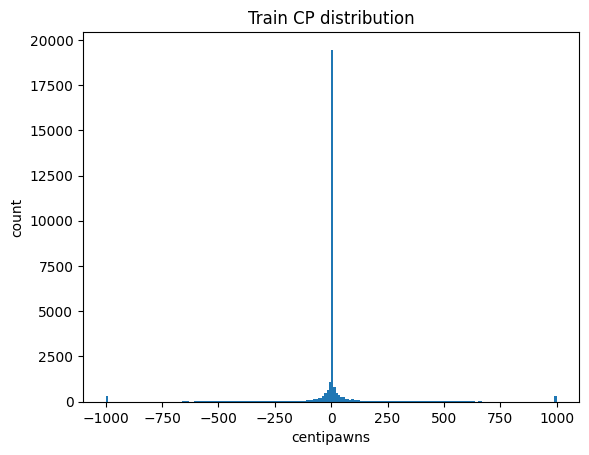

In [16]:
cps = []

for i in range(30000):
    cp = train_data[i]["target"].item() * 1000  # back to cp
    cps.append(cp)

cps = np.array(cps)

print("mean cp:", cps.mean())
print("std cp:", cps.std())
print("median cp:", np.median(cps))

pos = np.sum(cps > 0)
neg = np.sum(cps < 0)
zero = np.sum(cps == 0)

print("positive:", pos / len(cps))
print("negative:", neg / len(cps))
print("zero:", zero / len(cps))

plt.hist(cps, bins=200)
plt.title("Train CP distribution")
plt.xlabel("centipawns")
plt.ylabel("count")
plt.show()

In [171]:
def evaluate_fen(model, fen, device):
    import chess
    import torch

    board = chess.Board(fen)

    white_feats = extract_halfkp(board, chess.WHITE)
    black_feats = extract_halfkp(board, chess.BLACK)

    stm = 1.0 if board.turn == chess.WHITE else 0.0

    white_idx = torch.tensor(white_feats, dtype=torch.long, device=device)
    black_idx = torch.tensor(black_feats, dtype=torch.long, device=device)

    white_batch = torch.zeros(len(white_feats), dtype=torch.long, device=device)
    black_batch = torch.zeros(len(black_feats), dtype=torch.long, device=device)

    stm_tensor = torch.tensor([[stm]], dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        out = model(
            white_idx, white_batch,
            black_idx, black_batch,
            stm_tensor
        )

    # centipawn scale
    return out.item() * 1000.0

In [172]:
fen = "r1bqk1nr/pppp1ppp/2n5/2b1p1N1/2B1P3/8/PPPP1PPP/RNBQK2R b KQkq - 0 1"
print(evaluate_fen(model, fen, device))

fen2 = "r1bNk2r/pppp2pp/2n4n/2b1p3/2B1P3/8/PPPP1PPP/RNBQK2R w KQkq - 0 1"
print(evaluate_fen(model, fen2, device))

fen3 = "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq e3 0 1"
print(evaluate_fen(model, fen3, device))

13.384155929088593
13.384155929088593
13.384155929088593


In [87]:
import random
import chess
import numpy as np

def fen_key(board):
    """Ignore fullmove number by reconstructing canonical FEN without last field."""
    parts = board.fen().split()
    return " ".join(parts[:5])  # drops fullmove number

def halfkp_signature(board):
    stm = board.turn

    feats = extract_halfkp(
        board,
        chess.WHITE if stm else chess.BLACK
    )

    return (
        stm,
        tuple(sorted(feats))  # order-independent signature
    )

def collision_test(dataset, n=20000):
    seen = {}

    for i in range(n):
        item = dataset[i]
        board = chess.Board(item["fen"])

        key = fen_key(board)
        sig = halfkp_signature(board)

        if sig in seen:
            prev_fen = seen[sig]

            print("\n🚨 TRUE FEATURE COLLISION")
            print("FEN 1:", prev_fen)
            print("FEN 2:", item["fen"])
            return True

        seen[sig] = item["fen"]

    print("No collisions found in sample.")
    return False

collision_test(train_ds, n=50000)


🚨 TRUE FEATURE COLLISION
FEN 1: 8/8/7p/8/p4K1P/Pk4P1/8/8 b - -
FEN 2: 8/8/7p/8/p3K2P/Pk4P1/8/8 b - -


True

In [88]:
def print_halfkp(fen):
    board = chess.Board(fen)

    w = extract_halfkp(board, chess.WHITE)
    b = extract_halfkp(board, chess.BLACK)

    print("\nFEN:", fen)
    print("White features:", sorted(w))
    print("Black features:", sorted(b))
    print("Combined signature:", sorted(w + b))

fen1 = "8/8/7p/8/p4K1P/Pk4P1/8/8 b - -"
fen2 = "8/8/7p/8/p3K2P/Pk4P1/8/8 b - -"

print_halfkp(fen1)
print_halfkp(fen2)


FEN: 8/8/7p/8/p4K1P/Pk4P1/8/8 b - -
White features: [18576, 18582, 18591, 18648, 18671]
Black features: [26263, 26272, 26343, 26344, 26350]
Combined signature: [18576, 18582, 18591, 18648, 18671, 26263, 26272, 26343, 26344, 26350]

FEN: 8/8/7p/8/p3K2P/Pk4P1/8/8 b - -
White features: [17936, 17942, 17951, 18008, 18031]
Black features: [26263, 26272, 26343, 26344, 26350]
Combined signature: [17936, 17942, 17951, 18008, 18031, 26263, 26272, 26343, 26344, 26350]
